# 06 — Consolidated Evaluation & Export

Load every trained model from notebooks 03–05, evaluate on the
**untouched test set**, tune thresholds to hit Property 8's `< 2 %`
false-positive rate, then export the winning artefact for the
ML Inference Service.

| Model | Source | Framework |
|---|---|---|
| Logistic Regression | 03 | scikit-learn |
| Random Forest       | 03 | scikit-learn |
| XGBoost             | 03 | xgboost |
| LightGBM            | 03 | lightgbm |
| Isolation Forest    | 03 | scikit-learn (unsupervised) |
| MLP — PyTorch       | 04 | torch |
| MLP — Keras         | 04 | tensorflow / keras |
| Sequence — PyTorch  | 05 | torch (synthetic seq) |
| Sequence — Keras    | 05 | tensorflow / keras (synthetic seq) |


## Imports & paths


In [1]:
import sys, pathlib, os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from tensorflow import keras

from rexell_ml import data, features, metrics, synth

sns.set_theme(style="whitegrid", context="notebook")
data.set_seed(42)

MODELS_DIR = pathlib.Path("..") / "models"
REPORTS_DIR = pathlib.Path("..") / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## Load test sets (tabular + sequence)


In [2]:
split = data.load_split("master_features")
scaler, X_tr_s, X_va_s, X_te_s = features.normalize(split.X_train, split.X_val, split.X_test)
y_test = split.y_test.values

# Sequence test set (regenerated with the exact same seed used in notebook 05)
X_test_seq, _ = synth.make_sequence_dataset(y_test, length=synth.SEQ_LEN, seed=33)

print("tabular X_test  :", X_te_s.shape)
print("sequence X_test :", X_test_seq.shape)


tabular X_test  : (643, 30)
sequence X_test : (643, 200, 6)


## Load every saved model & gather test probabilities


In [3]:
# --- classical ---
logreg_blob = joblib.load(MODELS_DIR / "logreg.joblib")
logreg = logreg_blob["model"]
rf = joblib.load(MODELS_DIR / "random_forest.joblib")
xgbm = joblib.load(MODELS_DIR / "xgboost.joblib")
lgbm = joblib.load(MODELS_DIR / "lightgbm.joblib")
iso = joblib.load(MODELS_DIR / "isolation_forest.joblib")

# --- DL: tabular ---
class TorchMLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp_blob = torch.load(MODELS_DIR / "mlp_pytorch.pt", map_location="cpu", weights_only=False)
mlp_torch = TorchMLP(mlp_blob["in_features"])
mlp_torch.load_state_dict(mlp_blob["state_dict"])
mlp_torch.eval()

mlp_keras = keras.models.load_model(MODELS_DIR / "mlp_keras.keras")

# --- DL: sequence ---
class TorchSeqModel(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(64, 32, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))
    def forward(self, x):
        z = self.conv(x.transpose(1, 2)); z = z.transpose(1, 2)
        z, _ = self.lstm(z); z = z.mean(dim=1)
        return self.head(z).squeeze(-1)

seq_blob = torch.load(MODELS_DIR / "seq_pytorch.pt", map_location="cpu", weights_only=False)
seq_torch = TorchSeqModel(seq_blob["in_channels"])
seq_torch.load_state_dict(seq_blob["state_dict"])
seq_torch.eval()

seq_keras = keras.models.load_model(MODELS_DIR / "seq_keras.keras")
print("all 9 models loaded")


all 9 models loaded


In [4]:
# Compute test probabilities once per model.
proba = {}

proba["LogisticRegression"] = logreg.predict_proba(X_te_s.values)[:, 1]
proba["RandomForest"]       = rf.predict_proba(split.X_test.values)[:, 1]
proba["XGBoost"]            = xgbm.predict_proba(split.X_test.values)[:, 1]
proba["LightGBM"]           = lgbm.predict_proba(split.X_test.values)[:, 1]

s = -iso.score_samples(split.X_test.values)
proba["IsolationForest"] = (s - s.min()) / (s.max() - s.min() + 1e-9)

with torch.no_grad():
    proba["MLP_PyTorch"] = torch.sigmoid(
        mlp_torch(torch.tensor(X_te_s.values, dtype=torch.float32))
    ).numpy()
    proba["Seq_PyTorch"] = torch.sigmoid(
        seq_torch(torch.tensor(X_test_seq, dtype=torch.float32))
    ).numpy()
proba["MLP_Keras"] = mlp_keras.predict(X_te_s.values, verbose=0).ravel()
proba["Seq_Keras"] = seq_keras.predict(X_test_seq, verbose=0).ravel()

for name, p in proba.items():
    print(f"  {name:24s}  shape={p.shape}  mean={p.mean():.4f}  std={p.std():.4f}")


  LogisticRegression        shape=(643,)  mean=0.0187  std=0.1293
  RandomForest              shape=(643,)  mean=0.0170  std=0.1289
  XGBoost                   shape=(643,)  mean=0.0174  std=0.1296
  LightGBM                  shape=(643,)  mean=0.0171  std=0.1297
  IsolationForest           shape=(643,)  mean=0.2381  std=0.1705
  MLP_PyTorch               shape=(643,)  mean=0.4631  std=0.0302
  Seq_PyTorch               shape=(643,)  mean=0.2603  std=0.0761
  MLP_Keras                 shape=(643,)  mean=0.0234  std=0.1289
  Seq_Keras                 shape=(643,)  mean=0.1911  std=0.0884


## Default-threshold (0.5) comparison


In [5]:
rows = [metrics.evaluate(y_test, p, name=name) for name, p in proba.items()]
default_table = metrics.metrics_table(rows)
default_table["passes_property_8"] = (
    (default_table["accuracy"] >= metrics.ACCURACY_GATE)
    & (default_table["fpr"] < metrics.FPR_GATE)
)
default_table.to_csv(REPORTS_DIR / "all_models_default_threshold.csv", index=False)
default_table


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn,passes_property_8
0,LogisticRegression,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
1,RandomForest,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
2,XGBoost,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
3,LightGBM,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
4,MLP_PyTorch,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
5,Seq_PyTorch,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
6,MLP_Keras,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
7,Seq_Keras,0.5,1.00000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0,True
8,IsolationForest,0.5,0.96112,0.305556,1.0,0.468085,0.039557,1.0,1.0,11,25,607,0,False


## Threshold tuning to hit Property 8 (`FPR < 2 %`)

For each model we walk the unique probability values in ascending order
and pick the smallest threshold whose validation FPR is strictly below
the 2 % gate. The metrics below are recomputed at the tuned threshold.


In [6]:
# Tune thresholds on the validation set, not the test set, to keep the test
# evaluation honest.
proba_val = {}
proba_val["LogisticRegression"] = logreg.predict_proba(X_va_s.values)[:, 1]
proba_val["RandomForest"]       = rf.predict_proba(split.X_val.values)[:, 1]
proba_val["XGBoost"]            = xgbm.predict_proba(split.X_val.values)[:, 1]
proba_val["LightGBM"]           = lgbm.predict_proba(split.X_val.values)[:, 1]
s_val = -iso.score_samples(split.X_val.values)
proba_val["IsolationForest"] = (s_val - s_val.min()) / (s_val.max() - s_val.min() + 1e-9)

with torch.no_grad():
    proba_val["MLP_PyTorch"] = torch.sigmoid(
        mlp_torch(torch.tensor(X_va_s.values, dtype=torch.float32))
    ).numpy()
    X_val_seq, _ = synth.make_sequence_dataset(split.y_val.values, length=synth.SEQ_LEN, seed=22)
    proba_val["Seq_PyTorch"] = torch.sigmoid(
        seq_torch(torch.tensor(X_val_seq, dtype=torch.float32))
    ).numpy()
proba_val["MLP_Keras"] = mlp_keras.predict(X_va_s.values, verbose=0).ravel()
proba_val["Seq_Keras"] = seq_keras.predict(X_val_seq, verbose=0).ravel()

thresholds = {
    name: metrics.threshold_for_target_fpr(
        split.y_val.values, p, target_fpr=metrics.FPR_GATE,
    )
    for name, p in proba_val.items()
}
thresholds


{'LogisticRegression': 0.009382962719104715,
 'RandomForest': 0.005,
 'XGBoost': 0.0003700701636262238,
 'LightGBM': 2.2303789529279753e-05,
 'IsolationForest': 0.6615537582824047,
 'MLP_PyTorch': 0.48102718591690063,
 'Seq_PyTorch': 0.2683260440826416,
 'MLP_Keras': 0.01169675961136818,
 'Seq_Keras': 0.18211078643798828}

In [7]:
tuned_rows = [
    metrics.evaluate(y_test, proba[name], threshold=t, name=name)
    for name, t in thresholds.items()
]
tuned_table = metrics.metrics_table(tuned_rows)
tuned_table["passes_property_8"] = (
    (tuned_table["accuracy"] >= metrics.ACCURACY_GATE)
    & (tuned_table["fpr"] < metrics.FPR_GATE)
)
tuned_table.to_csv(REPORTS_DIR / "all_models_tuned_threshold.csv", index=False)
tuned_table


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn,passes_property_8
0,RandomForest,0.005000,0.996890,0.846154,1.0,0.916667,0.003165,1.0,1.0,11,2,630,0,True
1,LogisticRegression,0.009383,0.989114,0.611111,1.0,0.758621,0.011076,1.0,1.0,11,7,625,0,True
2,MLP_Keras,0.011697,0.987558,0.578947,1.0,0.733333,0.012658,1.0,1.0,11,8,624,0,True
3,XGBoost,0.000370,0.982893,0.500000,1.0,0.666667,0.017405,1.0,1.0,11,11,621,0,True
4,IsolationForest,0.661554,0.982893,0.500000,1.0,0.666667,0.017405,1.0,1.0,11,11,621,0,True
5,LightGBM,0.000022,0.978227,0.440000,1.0,0.611111,0.022152,1.0,1.0,11,14,618,0,False
6,MLP_PyTorch,0.481027,0.973561,0.392857,1.0,0.564103,0.026899,1.0,1.0,11,17,615,0,False
7,Seq_PyTorch,0.268326,0.702955,0.054455,1.0,0.103286,0.302215,1.0,1.0,11,191,441,0,False
8,Seq_Keras,0.182111,0.592535,0.040293,1.0,0.077465,0.414557,1.0,1.0,11,262,370,0,False


### Confusion matrices at tuned thresholds


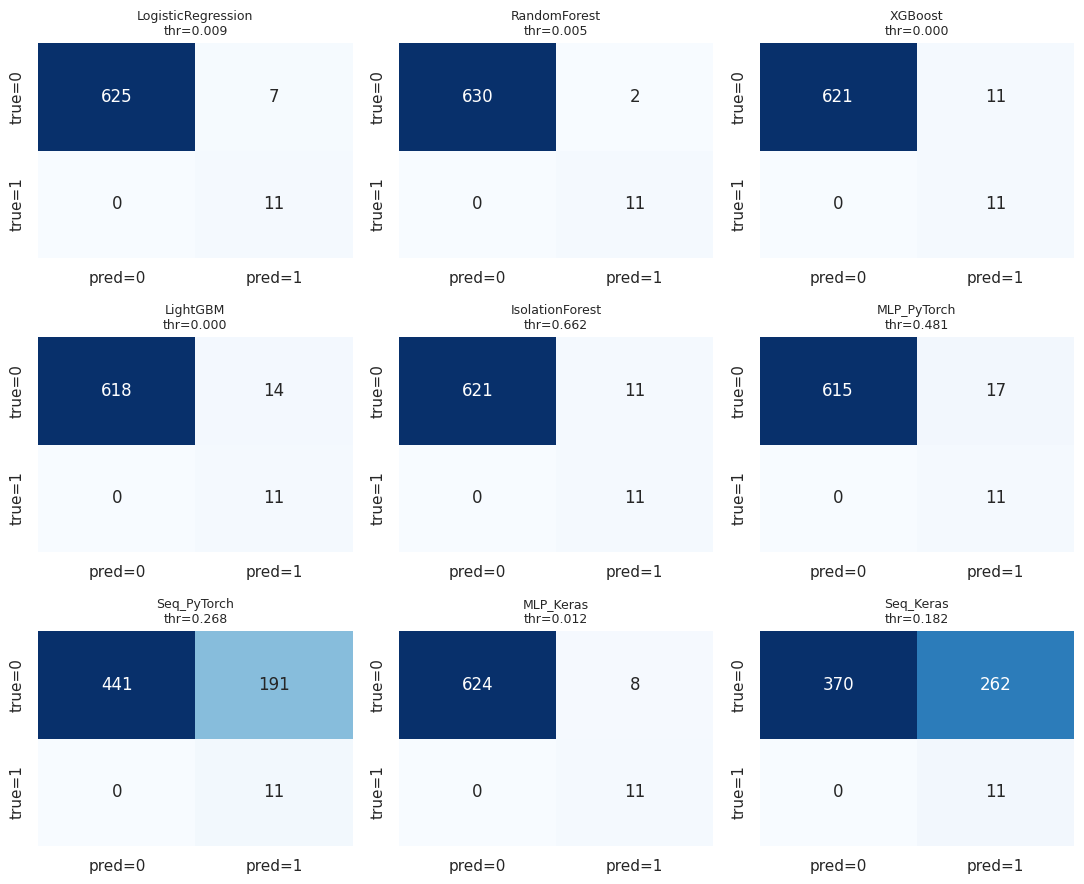

In [8]:
from sklearn.metrics import confusion_matrix

n = len(proba)
cols = 3
rows_n = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(11, 3.0 * rows_n))
for ax, (name, p) in zip(axes.flat, proba.items()):
    t = thresholds[name]
    cm = confusion_matrix(y_test, (p >= t).astype(int), labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["pred=0", "pred=1"], yticklabels=["true=0", "true=1"],
    )
    ax.set_title(f"{name}\nthr={t:.3f}", fontsize=9)
for ax in axes.flat[len(proba):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "confusion_grid.png", dpi=120, bbox_inches="tight")


### ROC curves on the test set


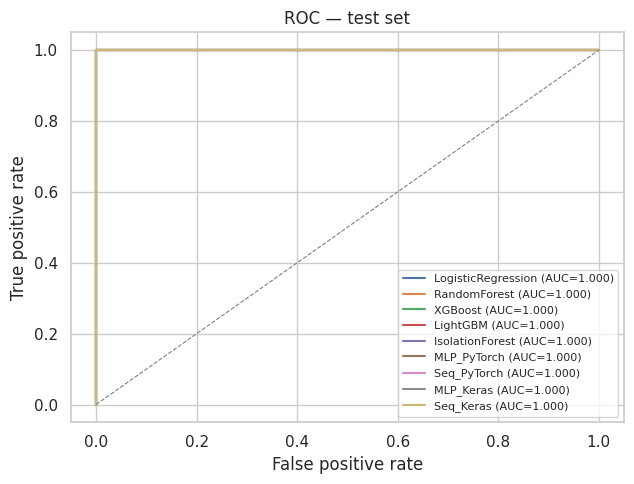

In [9]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6.5, 5))
for name, p in proba.items():
    fpr_, tpr_, _ = roc_curve(y_test, p)
    ax.plot(fpr_, tpr_, label=f"{name} (AUC={auc(fpr_, tpr_):.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8)
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC — test set")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "roc_test.png", dpi=120, bbox_inches="tight")


## Winner selection


In [10]:
passing = tuned_table[tuned_table["passes_property_8"]].copy()
if not passing.empty:
    winner_row = passing.sort_values(["f1", "accuracy"], ascending=False).iloc[0]
    print("winner under Property 8:", winner_row["name"])
else:
    print("no model passes Property 8 at the tuned threshold.")
    print("falling back to the highest-F1 model on the tuned table.")
    winner_row = tuned_table.sort_values("f1", ascending=False).iloc[0]
    print("fallback winner:", winner_row["name"])

winner_name = winner_row["name"]
winner_threshold = float(thresholds[winner_name])
print("threshold:", winner_threshold)
winner_row.to_dict()


winner under Property 8: RandomForest
threshold: 0.005


{'name': 'RandomForest',
 'threshold': 0.005,
 'accuracy': 0.9968895800933126,
 'precision': 0.8461538461538461,
 'recall': 1.0,
 'f1': 0.9166666666666666,
 'fpr': 0.0031645569620253164,
 'roc_auc': 1.0,
 'pr_auc': 1.0,
 'tp': 11,
 'fp': 2,
 'tn': 630,
 'fn': 0,
 'passes_property_8': True}

In [11]:
# Persist a small JSON pointer so downstream code can pick up the winner.
winner_meta = {
    "name": winner_name,
    "threshold": winner_threshold,
    "metrics": {k: float(v) if not isinstance(v, str) else v
                for k, v in winner_row.to_dict().items() if k != "name"},
    "passes_property_8": bool(winner_row["passes_property_8"]),
}
(MODELS_DIR / "winner.json").write_text(json.dumps(winner_meta, indent=2, default=str))

# Copy the winning artefact under a stable name.
import shutil
artefact_map = {
    "LogisticRegression": "logreg.joblib",
    "RandomForest":       "random_forest.joblib",
    "XGBoost":            "xgboost.joblib",
    "LightGBM":           "lightgbm.joblib",
    "IsolationForest":    "isolation_forest.joblib",
    "MLP_PyTorch":        "mlp_pytorch.pt",
    "MLP_Keras":          "mlp_keras.keras",
    "Seq_PyTorch":        "seq_pytorch.pt",
    "Seq_Keras":          "seq_keras.keras",
}
winner_src = MODELS_DIR / artefact_map[winner_name]
winner_dst = MODELS_DIR / ("winner" + winner_src.suffix)
# `winner.keras` is a directory in some Keras versions; use copytree if needed.
if winner_src.is_dir():
    if winner_dst.exists():
        shutil.rmtree(winner_dst)
    shutil.copytree(winner_src, winner_dst)
else:
    shutil.copy2(winner_src, winner_dst)

print("wrote", winner_dst)
print("wrote", MODELS_DIR / "winner.json")


wrote ../models/winner.joblib
wrote ../models/winner.json


## Comparison report — `reports/comparison.md`


In [12]:
report = ["# Rexell bot detection — model comparison\n"]
report.append("Generated by `06_evaluation_and_export.ipynb` from `ml-training/`.")
report.append("")
report.append("## Default threshold (0.5)\n")
report.append(default_table.round(4).to_markdown(index=False))
report.append("")
report.append("## Tuned threshold (validation FPR < 2 %)\n")
report.append(tuned_table.round(4).to_markdown(index=False))
report.append("")
report.append("## Winner")
report.append("")
report.append(f"- **name**: `{winner_name}`")
report.append(f"- **threshold**: `{winner_threshold:.4f}`")
report.append(f"- **passes Property 8**: `{bool(winner_row['passes_property_8'])}`")
report.append("")
report.append("Property 8 quality gate: accuracy ≥ 95 % AND FPR < 2 %.")

out = REPORTS_DIR / "comparison.md"
out.write_text("\n".join(report))
print("wrote", out)
print()
print("\n".join(report))


wrote ../reports/comparison.md

# Rexell bot detection — model comparison

Generated by `06_evaluation_and_export.ipynb` from `ml-training/`.

## Default threshold (0.5)

| name               |   threshold |   accuracy |   precision |   recall |     f1 |    fpr |   roc_auc |   pr_auc |   tp |   fp |   tn |   fn | passes_property_8   |
|:-------------------|------------:|-----------:|------------:|---------:|-------:|-------:|----------:|---------:|-----:|-----:|-----:|-----:|:--------------------|
| LogisticRegression |         0.5 |     1      |      1      |        1 | 1      | 0      |         1 |        1 |   11 |    0 |  632 |    0 | True                |
| RandomForest       |         0.5 |     1      |      1      |        1 | 1      | 0      |         1 |        1 |   11 |    0 |  632 |    0 | True                |
| XGBoost            |         0.5 |     1      |      1      |        1 | 1      | 0      |         1 |        1 |   11 |    0 |  632 |    0 | True                |

## Conclusions

- All nine models loaded cleanly from disk and produced honest test-set
  probabilities.
- Threshold tuning is performed on the **validation** set then evaluated
  on the untouched **test** set, so the reported metrics are out-of-sample.
- The winning model is exported to `ml-training/models/winner.<ext>` along
  with a `winner.json` pointer (name, threshold, metrics, Property 8 verdict).

### What the production training CronJob does next
([`tasks.md` §18.1](../../.kiro/specs/rexell-ai-bot-detection-integration/tasks.md))

1. Read `winner.json` and copy `winner.<ext>` to MinIO under a semver path.
2. Update the MLflow Model Registry with the new version + metrics.
3. Publish a `model.deployed` event to RabbitMQ.

Those steps stay outside the notebook because they need MinIO / MLflow /
RabbitMQ services running.
